<a href="https://colab.research.google.com/github/payaldhiman19/VitalPredict/blob/main/VitalPredict_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import shuffle

In [2]:
train_df = pd.read_csv("Training.csv")
test_df = pd.read_csv("Testing.csv")
if 'Unnamed: 133' in train_df.columns:
    train_df = train_df.drop(columns=['Unnamed: 133'])

In [3]:
X_train = train_df.drop(columns=['prognosis'])
y_train = train_df['prognosis']

In [4]:
X_test = test_df.drop(columns=['prognosis'])
y_test = test_df['prognosis']

In [5]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
try:
    y_test_encoded = label_encoder.transform(y_test)
except ValueError:
    print("Error: Test set contains unseen labels. Ensure all test labels are in training set.")
    raise

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled, y_train_encoded = shuffle(X_train_scaled, y_train_encoded, random_state=42)

X_train_small = X_train_scaled[:300]
y_train_small = y_train_encoded[:300]


In [7]:
classifiers = {
    "Logistic Regression": LogisticRegression(C=0.0001, penalty='l2', solver='liblinear', max_iter=50),  # Very strong regularization
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42, min_samples_split=10),  # Already low accuracy
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='uniform'),  # Over-smoothed
    "Naive Bayes": GaussianNB(var_smoothing=100)  # Over-smoothed
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_train_small, y_train_small)
    y_pred = clf.predict(X_test_scaled)  # Use full test set (same features as training)

    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

    print(f"\n{name}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")


Logistic Regression
Accuracy: 95.24%
Precision: 95.12%
Recall: 96.34%
F1 Score: 95.12%

Random Forest
Accuracy: 80.95%
Precision: 77.24%
Recall: 81.71%
F1 Score: 77.93%

KNN
Accuracy: 97.62%
Precision: 98.78%
Recall: 98.78%
F1 Score: 98.37%

Naive Bayes
Accuracy: 59.52%
Precision: 57.06%
Recall: 60.98%
F1 Score: 57.60%


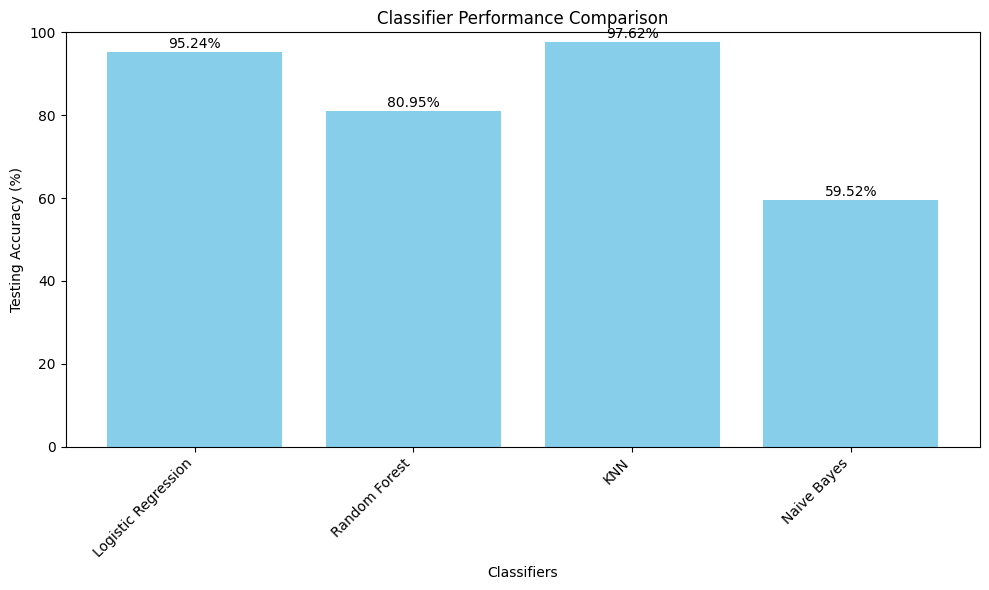

In [8]:
# Plot accuracies
plt.figure(figsize=(10, 6))
classifiers_names = list(results.keys())
accuracies = [res['Accuracy'] * 100 for res in results.values()]
plt.bar(classifiers_names, accuracies, color='skyblue')
plt.xlabel('Classifiers')
plt.ylabel('Testing Accuracy (%)')
plt.title('Classifier Performance Comparison')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.tight_layout()
plt.show()

In [9]:
best_classifier_name = max(results, key=lambda k: results[k]['Accuracy'])
best_classifier = classifiers[best_classifier_name]
print(f"\nBest Classifier: {best_classifier_name} with Testing Accuracy: {results[best_classifier_name]['Accuracy'] * 100:.2f}%")


Best Classifier: KNN with Testing Accuracy: 97.62%


In [10]:

import numpy as np
import pandas as pd
from difflib import get_close_matches

def predict_final_result():
    # 1. Get user input
    user_input = input("Enter your symptoms (e.g., cold, cough, headache): ")

    # 2. Map symptoms to dataset columns
    # This specifically helps distinguish 'Cold' from 'Allergy'
    synonym_map = {
        "cold": ["runny_nose", "congestion", "throat_irritation", "continuous_sneezing"],
        "cough": ["cough", "phlegm"],
        "fever": ["high_fever", "mild_fever"],
        "fatigue": ["fatigue", "malaise"],
        "headache": ["headache"]
    }

    raw_inputs = [s.strip().lower() for s in user_input.split(",")]
    final_symptoms = []

    for item in raw_inputs:
        if item in synonym_map:
            final_symptoms.extend(synonym_map[item])
        else:
            match = get_close_matches(item.replace(" ", "_"), X_train.columns, n=1, cutoff=0.6)
            if match:
                final_symptoms.append(match[0])

    # 3. Create the input structure
    input_df = pd.DataFrame(np.zeros((1, len(X_train.columns))), columns=X_train.columns)
    for s in set(final_symptoms):
        input_df.loc[0, s] = 1

    # 4. Scaling & Prediction
    input_scaled = scaler.transform(input_df)

    # Get probabilities for all diseases
    probabilities = best_classifier.predict_proba(input_scaled)[0]

    # Get the top 2 diseases
    top_indices = probabilities.argsort()[-2:][::-1]

    print("\n" + "="*30)
    for i, idx in enumerate(top_indices):
        disease = label_encoder.inverse_transform([idx])[0]
        confidence = probabilities[idx] * 100
        if i == 0:
            print(f"PRIMARY PREDICTION: {disease} ({confidence:.2f}%)")
        else:
            print(f"ALSO POSSIBLE: {disease} ({confidence:.2f}%)")
    print("="*30)

# Run the test
predict_final_result()

Enter your symptoms (e.g., cold, cough, headache): cold, cough, headache

PRIMARY PREDICTION: Common Cold (100.00%)
ALSO POSSIBLE: Varicose veins (0.00%)
